# PUBG Game Winner Prediction
---

## Project Documentation

### Problem Statement
PlayerUnknown's Battlegrounds (**PUBG**) is a battle-royale game where **up to 100 players** compete for survival. This project builds a **binary classification model** to predict whether a player will finish in the **top 10%** of their match (a near-win outcome), based on in-game performance statistics.

### Dataset
| Property | Detail |
|---|---|
| Source | PUBG Finish Placement Prediction (Kaggle) |
| File | `Data/pubg.csv` |
| Rows | ~4.4 million players |
| Target | `winner` — 1 if `winPlacePerc ≥ 0.90`, else 0 |
| Class Balance | ~89% No Win / ~11% Win |

### Features Overview
| Feature | Type | Description |
|---|---|---|
| `kills` | Numeric | Number of enemy kills |
| `damageDealt` | Numeric | Total damage dealt to enemies |
| `walkDistance` | Numeric | Distance walked on foot (metres) |
| `boosts` | Numeric | Boost items used |
| `weaponsAcquired` | Numeric | Total weapons picked up |
| `heals` | Numeric | Healing items used |
| `killPlace` | Numeric | Kill rank within match |
| `rideDistance` | Numeric | Distance travelled by vehicle |
| `matchType` | Categorical | Game mode (solo, duo, squad, fpp/tpp) |
| `winPlacePerc` | Float | **Source for target**: finish-place percentile (0–1) |

### Pipeline Summary
```
Data Loading → EDA → Outlier Analysis → Feature Engineering
    → Encoding → Scaling → Train/Test Split
        → 6 ML Models → Comparison → Best Model Deep Dive
```

### Libraries Used
- **Data**: `pandas`, `numpy`
- **Visualization**: `matplotlib`, `seaborn`
- **Preprocessing**: `sklearn.preprocessing`, `LabelEncoder`
- **Modelling**: `sklearn` (Logistic Regression, KNN, Decision Tree, Random Forest, Gradient Boosting, SVM)
- **Evaluation**: `sklearn.metrics`

---


##  Section 1 — Import Libraries

In [2]:
# Standard Libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Sklearn Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Plot Styling
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

print(" All libraries imported successfully!")


 All libraries imported successfully!


##  Section 2 — Data Loading & Initial Inspection

In [3]:
# Load Dataset  (sample 200k rows for faster training)
df = pd.read_csv('pubg.csv', nrows=200000)

# Drop ID columns — not useful for prediction
df.drop(columns=['Id', 'groupId', 'matchId'], inplace=True, errors='ignore')

# Create binary target — Top 10% finish = Winner
df['winner'] = (df['winPlacePerc'] >= 0.90).astype(int)
df.drop(columns=['winPlacePerc'], inplace=True)

print(f" Data loaded successfully!")
print(f"   Shape   : {df.shape}  ({df.shape[0]:,} players × {df.shape[1]} columns)")
print(f"   Columns : {list(df.columns)}")
df.head(10)


 Data loaded successfully!
   Shape   : (200000, 26)  (200,000 players × 26 columns)
   Columns : ['assists', 'boosts', 'damageDealt', 'DBNOs', 'headshotKills', 'heals', 'killPlace', 'killPoints', 'kills', 'killStreaks', 'longestKill', 'matchDuration', 'matchType', 'maxPlace', 'numGroups', 'rankPoints', 'revives', 'rideDistance', 'roadKills', 'swimDistance', 'teamKills', 'vehicleDestroys', 'walkDistance', 'weaponsAcquired', 'winPoints', 'winner']


,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winner
0,0,0,0.000,0,0,0,60,1241,0,0,...,0,0.0000,0,0.00,0,0,244.80,1,1466,0
1,0,0,91.470,0,0,0,57,0,0,0,...,0,0.0045,0,11.04,0,0,1434.00,5,0,0
2,1,0,68.000,0,0,0,47,0,0,0,...,0,0.0000,0,0.00,0,0,161.80,2,0,0
3,0,0,32.900,0,0,0,75,0,0,0,...,0,0.0000,0,0.00,0,0,202.70,3,0,0
4,0,0,100.000,0,0,0,45,0,1,1,...,0,0.0000,0,0.00,0,0,49.75,2,0,0
5,0,0,100.000,1,1,0,44,0,1,1,...,0,0.0000,0,0.00,0,0,34.70,1,0,0
6,0,0,0.000,0,0,0,96,1262,0,0,...,0,0.0000,0,0.00,0,0,13.50,1,1497,0
7,0,0,8.538,0,0,0,48,1000,0,0,...,0,2004.0000,0,0.00,0,0,1089.00,6,1500,0
8,0,0,51.600,0,0,0,64,0,0,0,...,0,0.0000,0,0.00,0,0,799.90,4,0,0
9,0,0,37.270,0,0,0,74,0,0,0,...,0,0.0000,0,0.00,0,0,65.67,1,0,0


## Inside the Dataset
The dataset contains rich in-game statistics for each PUBG player per match. The target column `winner` represents whether a player finished in the **top 10%** of their match (a near-victory outcome):

- `1` → **Top 10% Finish (Winner Zone)**
- `0` → **Did Not Reach Top 10%**

Features capture different aspects of gameplay: aggression (kills, damageDealt), survival (walkDistance, heals, boosts), and vehicle use (rideDistance). The `matchType` column identifies the game mode and is encoded before modelling.


In [4]:
# Data Types & Memory Usage
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 26 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   assists          200000 non-null  int64  
 1   boosts           200000 non-null  int64  
 2   damageDealt      200000 non-null  float64
 3   DBNOs            200000 non-null  int64  
 4   headshotKills    200000 non-null  int64  
 5   heals            200000 non-null  int64  
 6   killPlace        200000 non-null  int64  
 7   killPoints       200000 non-null  int64  
 8   kills            200000 non-null  int64  
 9   killStreaks      200000 non-null  int64  
 10  longestKill      200000 non-null  float64
 11  matchDuration    200000 non-null  int64  
 12  matchType        200000 non-null  object 
 13  maxPlace         200000 non-null  int64  
 14  numGroups        200000 non-null  int64  
 15  rankPoints       200000 non-null  int64  
 16  revives          200000 non-null  int6

## Dataset Info
The dataset spans numeric (int64, float64) and one categorical column (`matchType`). All columns have complete non-null values, so no imputation is required. Dropping ID columns eliminates data-leakage risk. The binary target `winner` is created from `winPlacePerc`.


In [5]:
# Statistical Summary
df.describe()


,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,killPoints,kills,killStreaks,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winner
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.00000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.232945,1.112545,130.764752,0.655985,0.22603,1.367785,47.645770,506.908240,0.925240,0.543795,...,0.163080,601.942806,0.003605,4.545029,0.023500,0.007455,1155.736676,3.672375,609.192020,0.105275
std,0.590604,1.723584,171.826055,1.148558,0.59966,2.667927,27.471291,627.521631,1.564654,0.712604,...,0.466118,1483.874136,0.076825,30.746094,0.165553,0.089663,1184.376026,2.472826,740.250459,0.306908
min,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,24.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,155.400000,2.000000,0.000000,0.000000
50%,0.000000,0.000000,84.000000,0.000000,0.00000,0.000000,48.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,689.150000,3.000000,0.000000,0.000000
75%,0.000000,2.000000,185.500000,1.000000,0.00000,2.000000,71.000000,1172.000000,1.000000,1.000000,...,0.000000,0.034725,0.000000,0.000000,0.000000,0.000000,1978.000000,5.000000,1495.000000,0.000000
max,21.000000,21.000000,5479.000000,32.000000,40.00000,52.000000,100.000000,2152.000000,48.000000,14.000000,...,16.000000,28450.000000,8.000000,2295.000000,5.000000,4.000000,13530.000000,72.000000,1972.000000,1.000000


In [6]:
# Null Values & Duplicates Check
null_counts = df.isnull().sum()
print("Null values per column:")
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else " No null values found!")

print(f"\nDuplicate rows : {df.duplicated().sum()}")


Null values per column:
 No null values found!

Duplicate rows : 9


##  Section 3 — Exploratory Data Analysis (EDA)

> We explore distributions, class balance, relationships between features, and correlations.


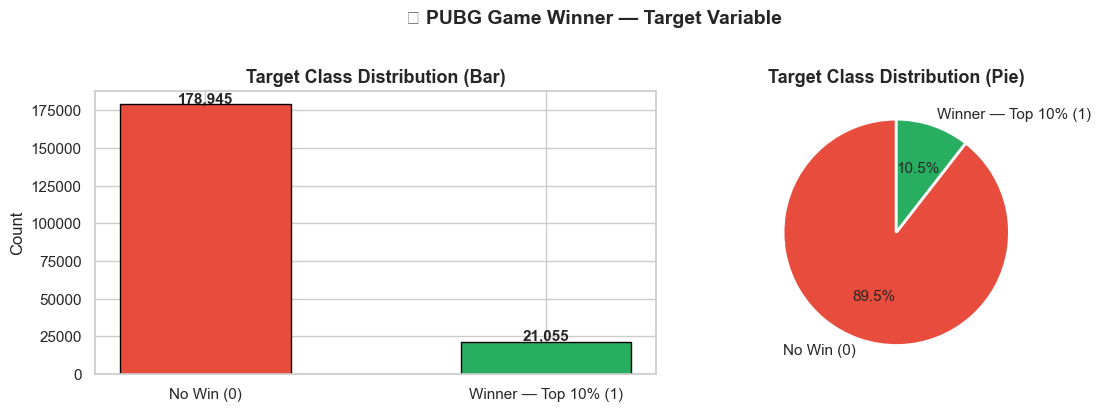


  Class Distribution:
   No Win  : 178,945 (89.5%)
   Winner  : 21,055 (10.5%)


In [7]:
# Target Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['winner'].value_counts().sort_index()
labels = ['No Win (0)', 'Winner — Top 10% (1)']
colors = ['#e74c3c', '#27ae60']

# Bar chart
axes[0].bar(labels, target_counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Target Class Distribution (Bar)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Target Class Distribution (Pie)', fontsize=13, fontweight='bold')

plt.suptitle('🎮 PUBG Game Winner — Target Variable', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n  Class Distribution:")
print(f"   No Win  : {target_counts[0]:,} ({target_counts[0]/len(df)*100:.1f}%)")
print(f"   Winner  : {target_counts[1]:,} ({target_counts[1]/len(df)*100:.1f}%)")


## Insights from Target Distribution
- The dataset has a **class imbalance**: approximately 89% of players do not finish in the top 10%, while ~11% do.
- This imbalance is realistic — only one squad wins per match. Models need to handle this via stratified splitting or class-weight balancing.
- The minority class (winners) still provides thousands of positive examples for learning.


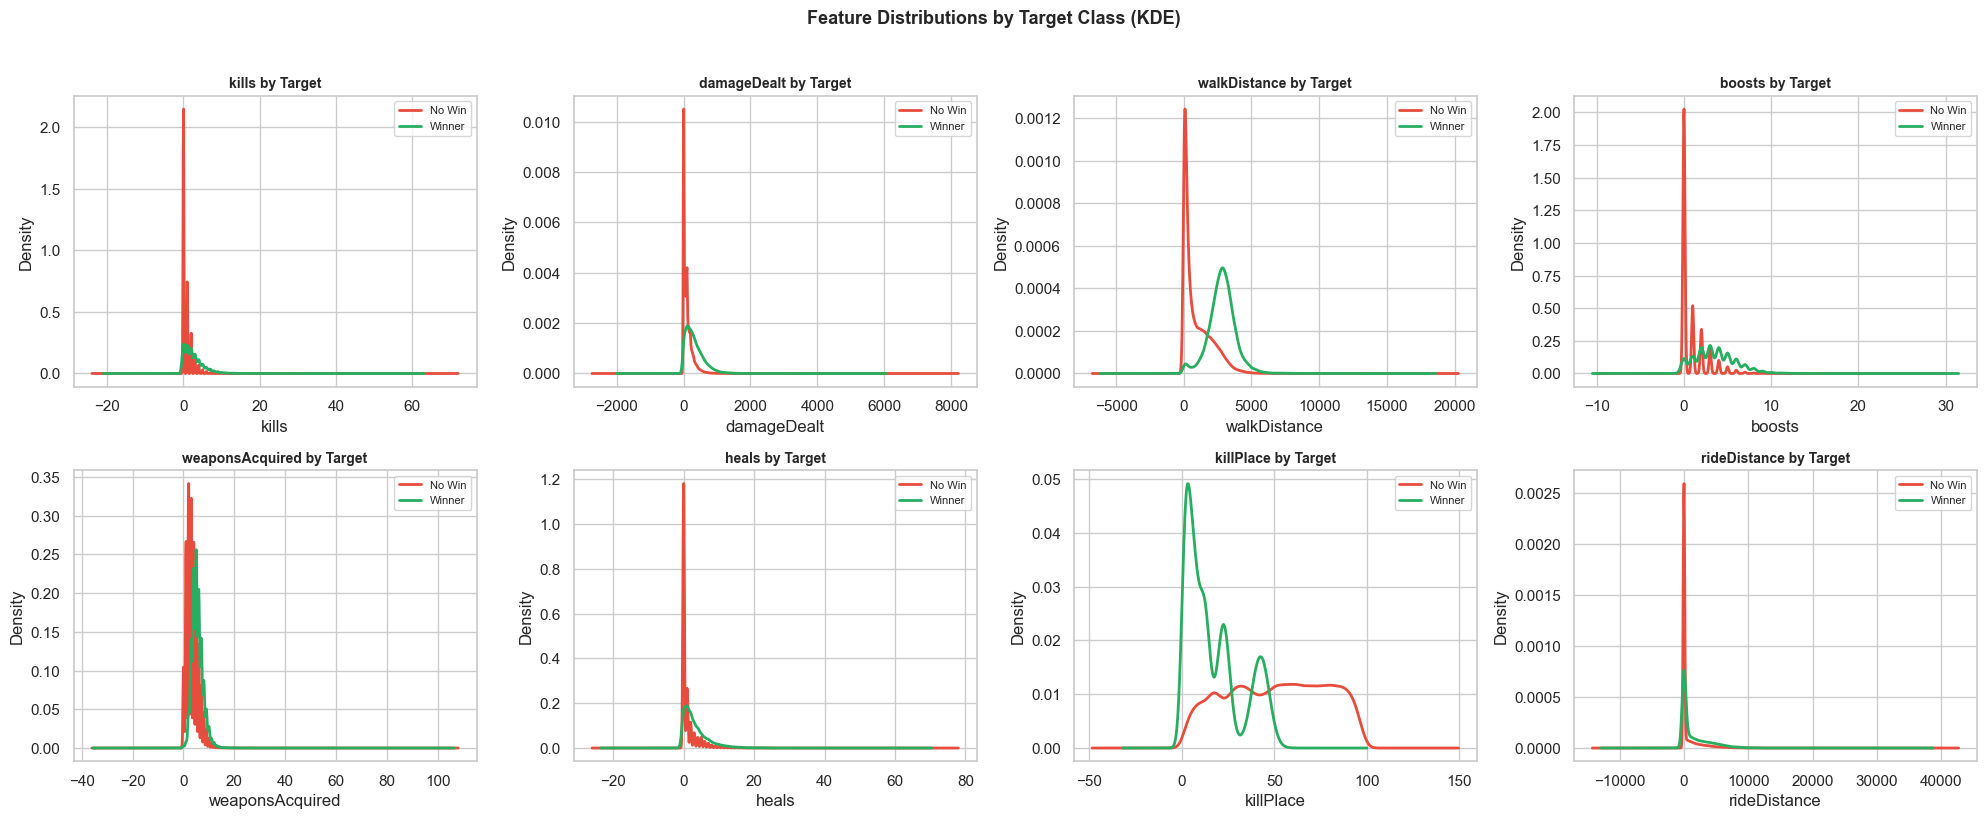

In [8]:
# Feature vs Target (KDE Plots)
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
kde_features = ['kills', 'damageDealt', 'walkDistance', 'boosts',
                'weaponsAcquired', 'heals', 'killPlace', 'rideDistance']
colors_kde = {0: '#e74c3c', 1: '#27ae60'}

for idx, col in enumerate(kde_features):
    row, col_idx = divmod(idx, 4)
    for target_val in [0, 1]:
        subset = df[df['winner'] == target_val][col]
        subset.plot(kind='kde', ax=axes[row, col_idx],
                    label=f'{"Winner" if target_val else "No Win"}',
                    color=colors_kde[target_val], linewidth=2)
    axes[row, col_idx].set_title(f'{col} by Target', fontsize=10, fontweight='bold')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].legend(fontsize=8)

plt.suptitle('Feature Distributions by Target Class (KDE)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Insights from Feature Distributions & Outlier Detection
- Most features are **right-skewed**: the majority of players have low kill counts, low damage, and short walk distances — consistent with early eliminations.
- `killPlace` is more uniformly distributed since it's a rank-based column.
- `walkDistance` has a wide spread, indicating it's a strong survival signal (survivors walk further).
- Outliers exist in `kills`, `damageDealt`, `longestKill`, and `rideDistance`, representing elite players. These are real game events and should be capped rather than removed.


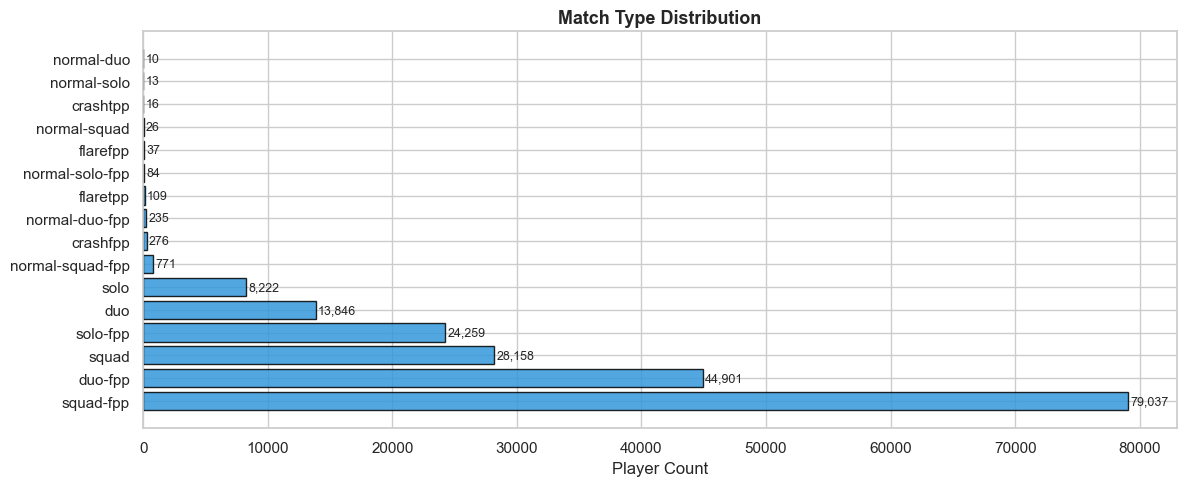

In [9]:
# Match Type Distribution
plt.figure(figsize=(12, 5))
match_counts = df['matchType'].value_counts()
bars = plt.barh(match_counts.index, match_counts.values, color='#3498db', edgecolor='black', alpha=0.85)
plt.title('Match Type Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Player Count')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 200, bar.get_y() + bar.get_height()/2,
             f'{int(width):,}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


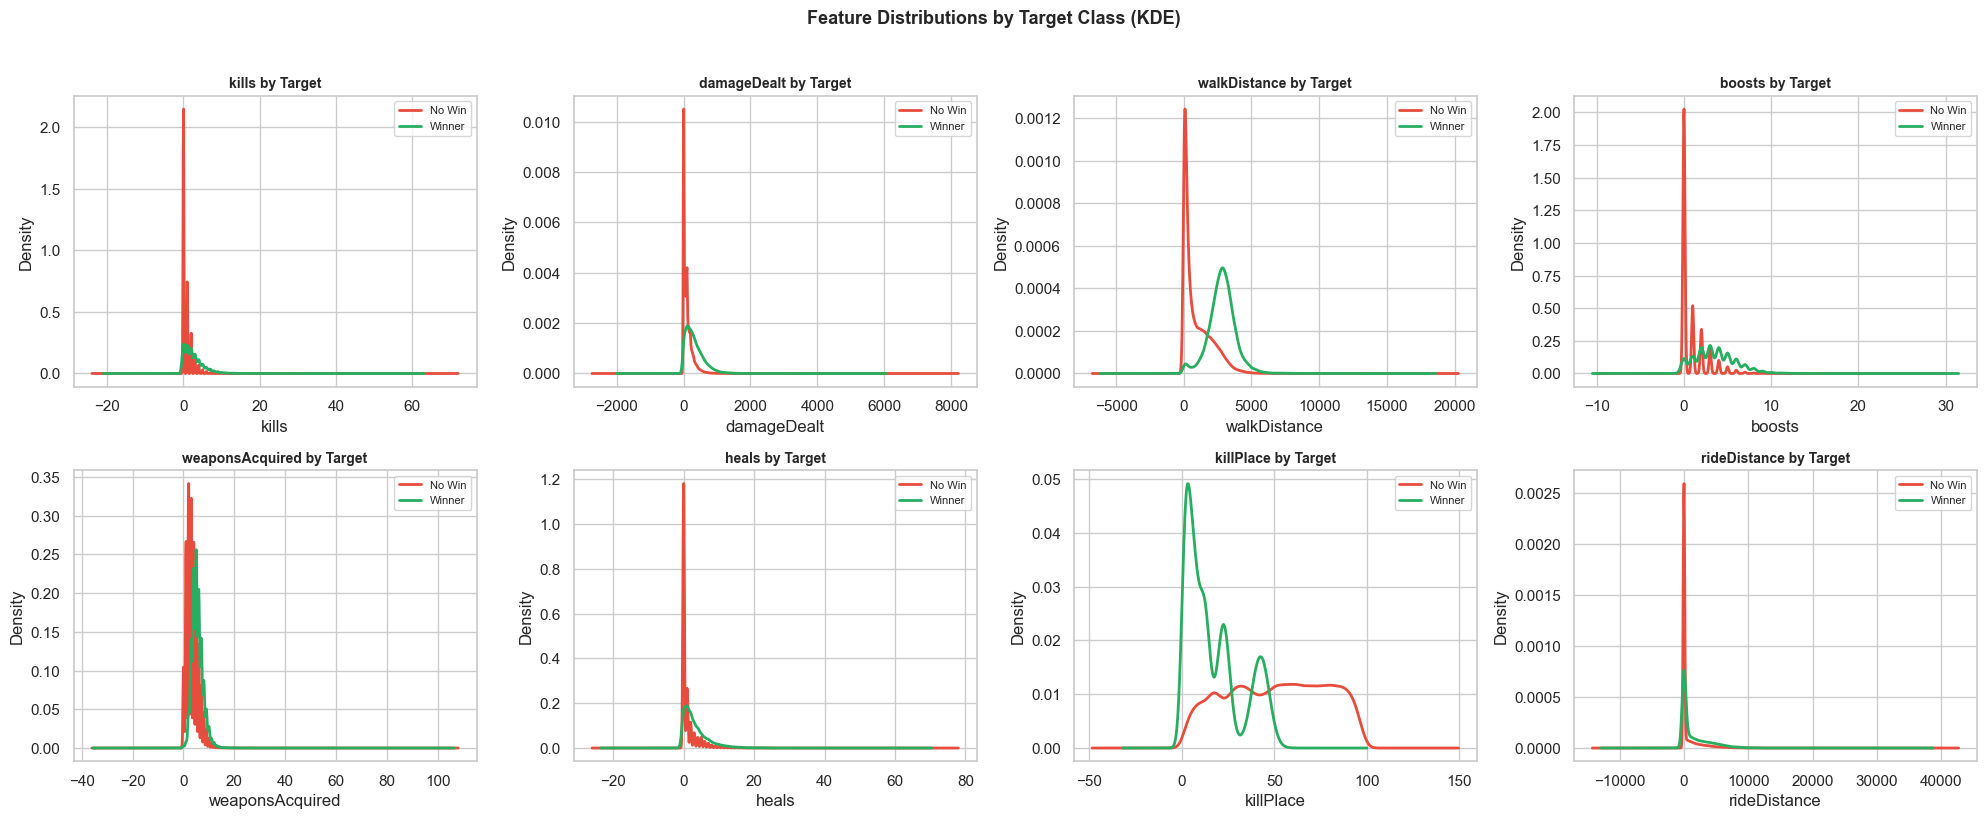

In [10]:
# Feature vs Target (KDE Plots)
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
kde_features = ['kills', 'damageDealt', 'walkDistance', 'boosts',
                'weaponsAcquired', 'heals', 'killPlace', 'rideDistance']
colors_kde = {0: '#e74c3c', 1: '#27ae60'}

for idx, col in enumerate(kde_features):
    row, col_idx = divmod(idx, 4)
    for target_val in [0, 1]:
        subset = df[df['winner'] == target_val][col]
        subset.plot(kind='kde', ax=axes[row, col_idx],
                    label=f'{"Winner" if target_val else "No Win"}',
                    color=colors_kde[target_val], linewidth=2)
    axes[row, col_idx].set_title(f'{col} by Target', fontsize=10, fontweight='bold')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].legend(fontsize=8)

plt.suptitle('Feature Distributions by Target Class (KDE)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Insights from Feature Distributions by Target Class (KDE)
- **walkDistance** shows the clearest separation: winners walk significantly farther, confirming survival/movement is the strongest predictor.
- **damageDealt** and **kills**: winners tend to deal more damage, but many winners survive without many kills (ring strategy).
- **boosts** and **heals**: winners use significantly more consumables — direct survival indicators.
- **killPlace** (kill rank): winners have lower kill-place ranks, meaning their kill rate is relatively high.
- **rideDistance** has heavily overlapping distributions, suggesting vehicle use alone is not a strong differentiator.


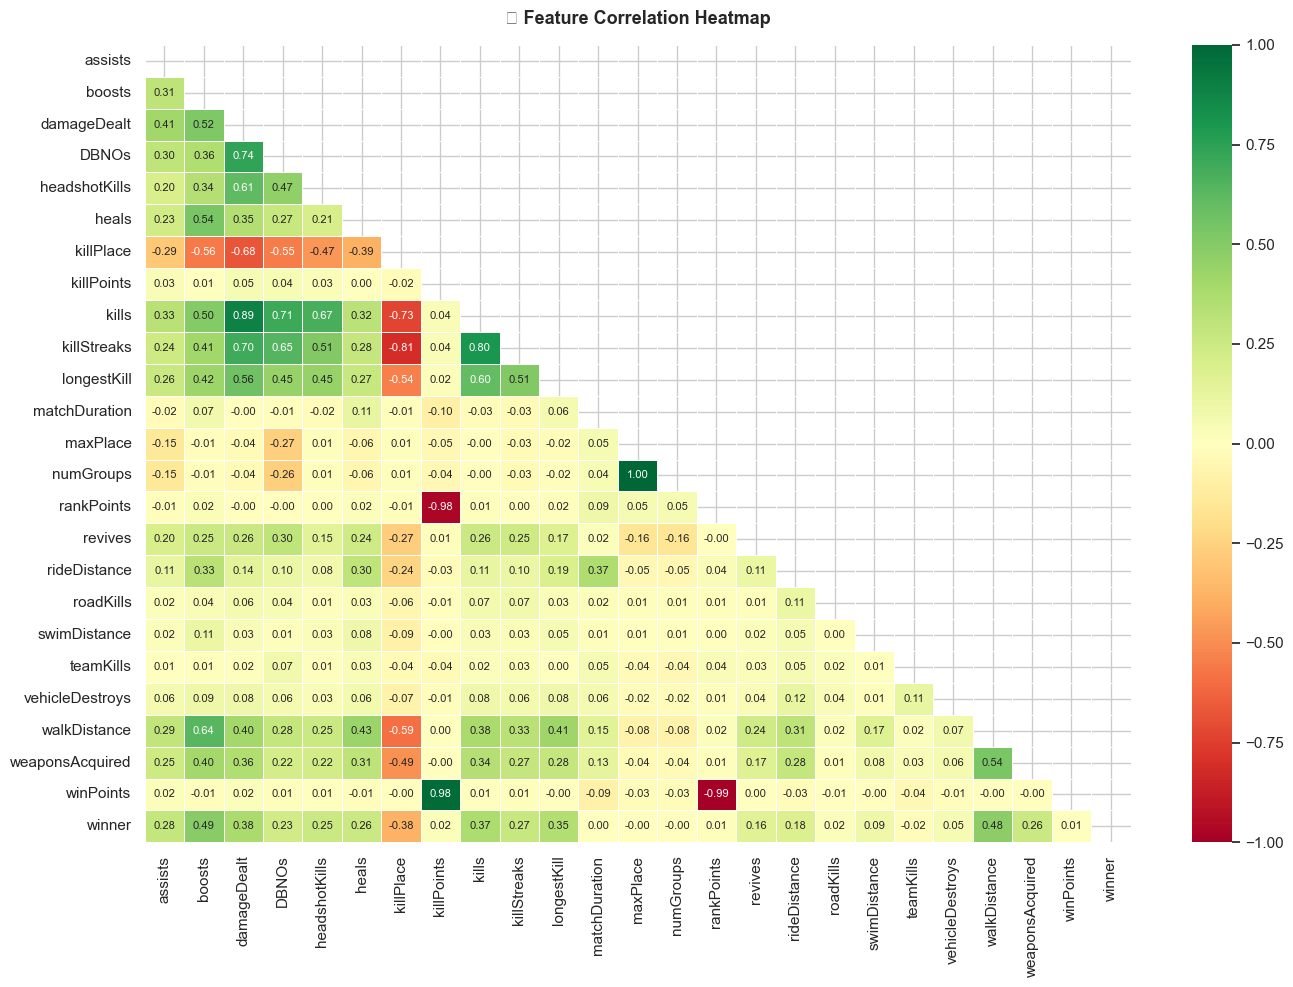


🔑 Key Correlations with Target (winner):
boosts             0.490949
walkDistance       0.482509
damageDealt        0.378499
kills              0.373187
longestKill        0.349347
assists            0.283055
killStreaks        0.265735
weaponsAcquired    0.256297
heals              0.255130
headshotKills      0.253938
DBNOs              0.229691
rideDistance       0.180033
revives            0.161000
swimDistance       0.088833
vehicleDestroys    0.051609
roadKills          0.023135
killPoints         0.017360
rankPoints         0.008129
winPoints          0.006801
matchDuration      0.003739
maxPlace          -0.001012
numGroups         -0.001273
teamKills         -0.018382
killPlace         -0.381489


In [11]:
# Correlation Heatmap (numeric features only)
plt.figure(figsize=(14, 10))
num_df = df.select_dtypes(include=[np.number])
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, linecolor='white',
            vmin=-1, vmax=1, annot_kws={'size': 8})
plt.title('🎮 Feature Correlation Heatmap', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n🔑 Key Correlations with Target (winner):")
print(corr['winner'].drop('winner').sort_values(ascending=False).to_string())


## Insights from Correlation Heatmap
- **walkDistance** has the highest positive correlation with `winner` — the single most important raw feature.
- **boosts** and **weaponsAcquired** also show strong positive correlation, reflecting active gameplay.
- **killPlace** has a strong **negative** correlation — lower kill-rank (better killer) = more likely to win.
- **kills** and **damageDealt** have moderate positive correlations.
- `killPoints` and `winPoints` may introduce data leakage (they are ranking-system scores, not pure in-match stats). We will drop them in preprocessing.


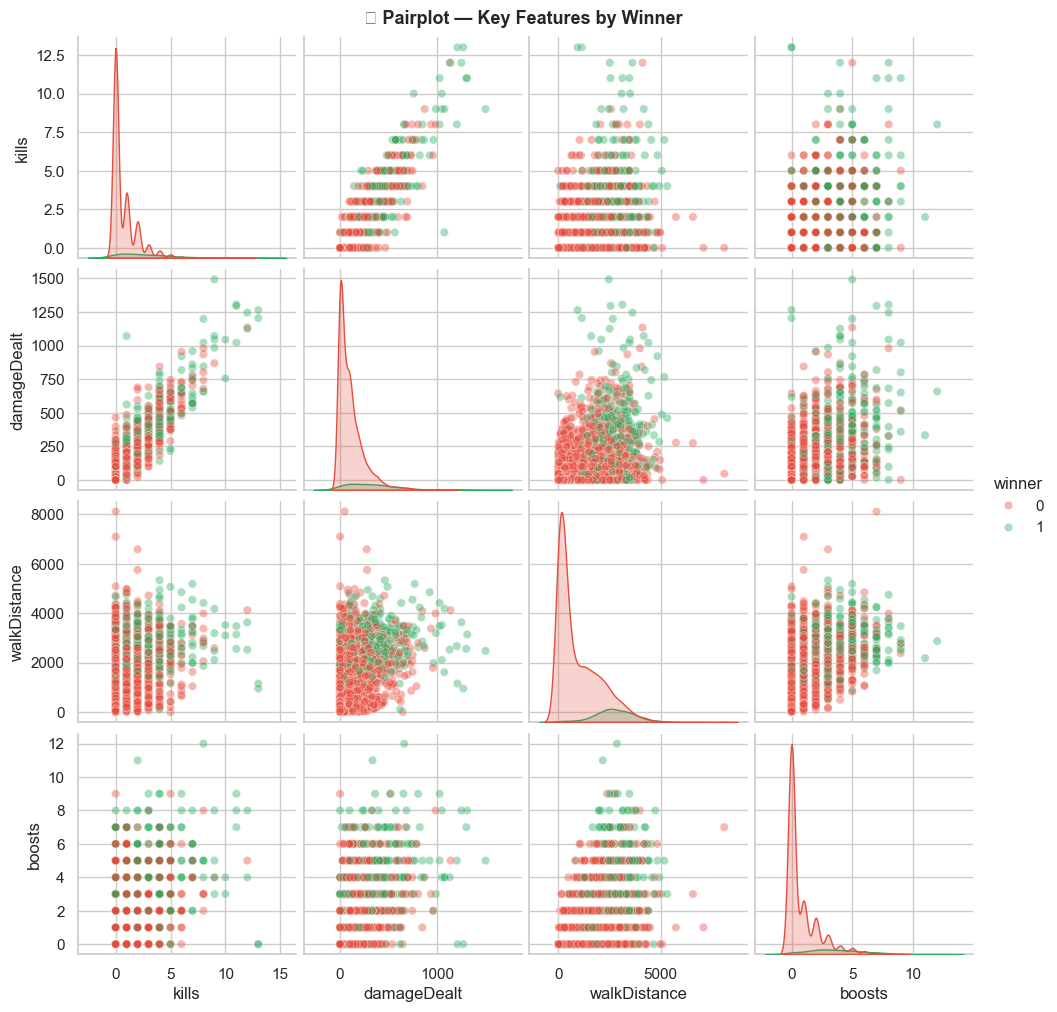

In [12]:
# Pairplot (sample for speed)
sample_df = df.sample(3000, random_state=42)
pair_cols = ['kills', 'damageDealt', 'walkDistance', 'boosts', 'winner']
sns.pairplot(sample_df[pair_cols], hue='winner',
             palette={0: '#e74c3c', 1: '#27ae60'},
             diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('🎮 Pairplot — Key Features by Winner', y=1.01, fontsize=13, fontweight='bold')
plt.show()


## 🔍 Section 4 — Outlier Analysis

> We use the **IQR method** to detect and assess outliers in each numeric feature.


In [13]:
# IQR-Based Outlier Detection
num_cols = df.select_dtypes(include=[np.number]).columns.drop('winner').tolist()
print("🔍 Outlier Summary (IQR Method)")
print("-" * 65)

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    pct = len(outliers) / len(df) * 100
    print(f"  {col:<25} Outliers: {len(outliers):>7,}  ({pct:5.1f}%)   Range: [{lower:.1f}, {upper:.1f}]")

print("-" * 65)
print("\n Note: Outliers retained — extreme players are genuine game events.")
print("   Consider Winsorization (percentile capping) if model performance suffers.")


🔍 Outlier Summary (IQR Method)
-----------------------------------------------------------------
  assists                   Outliers:  34,844  ( 17.4%)   Range: [0.0, 0.0]
  boosts                    Outliers:   6,514  (  3.3%)   Range: [-3.0, 5.0]
  damageDealt               Outliers:   9,911  (  5.0%)   Range: [-278.2, 463.8]
  DBNOs                     Outliers:  13,183  (  6.6%)   Range: [-1.5, 2.5]
  headshotKills             Outliers:  33,774  ( 16.9%)   Range: [0.0, 0.0]
  heals                     Outliers:  14,591  (  7.3%)   Range: [-3.0, 5.0]
  killPlace                 Outliers:       0  (  0.0%)   Range: [-46.5, 141.5]
  killPoints                Outliers:       0  (  0.0%)   Range: [-1758.0, 2930.0]
  kills                     Outliers:  23,258  ( 11.6%)   Range: [-1.5, 2.5]
  killStreaks               Outliers:   2,353  (  1.2%)   Range: [-1.5, 2.5]
  longestKill               Outliers:  27,643  ( 13.8%)   Range: [-31.7, 52.8]
  matchDuration             Outliers:     1

## ⚙️ Section 5 — Feature Engineering & Preprocessing

> We engineer meaningful new features, encode categoricals, drop leakage columns, and apply **StandardScaler**.


In [14]:
# Drop columns that leak target or add no predictive value
leakage_cols = ['killPoints', 'winPoints', 'rankPoints']
df.drop(columns=[c for c in leakage_cols if c in df.columns], inplace=True)

print("✅ Leakage columns dropped:", leakage_cols)
print(f"   Remaining columns: {list(df.columns)}")


✅ Leakage columns dropped: ['killPoints', 'winPoints', 'rankPoints']
   Remaining columns: ['assists', 'boosts', 'damageDealt', 'DBNOs', 'headshotKills', 'heals', 'killPlace', 'kills', 'killStreaks', 'longestKill', 'matchDuration', 'matchType', 'maxPlace', 'numGroups', 'revives', 'rideDistance', 'roadKills', 'swimDistance', 'teamKills', 'vehicleDestroys', 'walkDistance', 'weaponsAcquired', 'winner']


In [15]:
# Feature Engineering
# 1. Kill Efficiency — kills per unit of damage dealt
df['Kill_Efficiency']   = df['kills'] / (df['damageDealt'] + 1)

# 2. Survival Score — movement + healing intensity
df['Survival_Score']    = df['walkDistance'] * 0.4 + df['heals'] * 10 + df['boosts'] * 15

# 3. Combat Score — aggression metric
df['Combat_Score']      = df['damageDealt'] * 0.5 + df['kills'] * 20

# 4. Headshot Rate — precision indicator
df['Headshot_Rate']     = df['headshotKills'] / (df['kills'] + 1)

# 5. Total Distance — overall mobility
df['Total_Distance']    = df['walkDistance'] + df['rideDistance'] + df['swimDistance']

print("✅ Feature Engineering Done!")
print("   New features: Kill_Efficiency, Survival_Score, Combat_Score, Headshot_Rate, Total_Distance")
df[['Kill_Efficiency', 'Survival_Score', 'Combat_Score', 'Headshot_Rate', 'Total_Distance']].head()


✅ Feature Engineering Done!
   New features: Kill_Efficiency, Survival_Score, Combat_Score, Headshot_Rate, Total_Distance


,Kill_Efficiency,Survival_Score,Combat_Score,Headshot_Rate,Total_Distance
0,0.000000,97.92,0.000,0.0,244.8000
1,0.000000,573.60,45.735,0.0,1445.0445
2,0.000000,64.72,34.000,0.0,161.8000
3,0.000000,81.08,16.450,0.0,202.7000
4,0.009901,19.90,70.000,0.0,49.7500


## New Features Created
| Feature | Description |
|---|---|
| `Kill_Efficiency` | Kills per damage dealt — measures how lethal each damage point is |
| `Survival_Score` | Weighted mix of walking, heals, and boosts — pure survival metric |
| `Combat_Score` | Weighted aggression score combining damage and kills |
| `Headshot_Rate` | Precision metric — fraction of kills via headshots |
| `Total_Distance` | Combined movement (foot + vehicle + swim) |

These composite features capture gameplay **strategy** beyond individual raw stats and are expected to improve model discrimination.


In [16]:
# Encode Categorical Feature — matchType
le = LabelEncoder()
df['matchType_enc'] = le.fit_transform(df['matchType'])
df.drop(columns=['matchType'], inplace=True)

print("✅ matchType encoded into matchType_enc")
print(f"   Classes: {list(le.classes_)}")


✅ matchType encoded into matchType_enc
   Classes: ['crashfpp', 'crashtpp', 'duo', 'duo-fpp', 'flarefpp', 'flaretpp', 'normal-duo', 'normal-duo-fpp', 'normal-solo', 'normal-solo-fpp', 'normal-squad', 'normal-squad-fpp', 'solo', 'solo-fpp', 'squad', 'squad-fpp']


In [17]:
# Separate Features & Target
X = df.drop(columns=['winner'])
y = df['winner']

feature_names = X.columns.tolist()
print(f"Feature columns ({len(feature_names)}): {feature_names}")
print(f"\nX shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())


Feature columns (27): ['assists', 'boosts', 'damageDealt', 'DBNOs', 'headshotKills', 'heals', 'killPlace', 'kills', 'killStreaks', 'longestKill', 'matchDuration', 'maxPlace', 'numGroups', 'revives', 'rideDistance', 'roadKills', 'swimDistance', 'teamKills', 'vehicleDestroys', 'walkDistance', 'weaponsAcquired', 'Kill_Efficiency', 'Survival_Score', 'Combat_Score', 'Headshot_Rate', 'Total_Distance', 'matchType_enc']

X shape : (200000, 27)
y shape : (200000,)

Target distribution:
winner
0    178945
1     21055
Name: count, dtype: int64


In [18]:
# Train / Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set : {X_train.shape[0]:,} samples")
print(f"Test set  : {X_test.shape[0]:,} samples")
print(f"\nTrain target distribution:")
print(y_train.value_counts())
print(f"\nTest target distribution:")
print(y_test.value_counts())


Train set : 160,000 samples
Test set  : 40,000 samples

Train target distribution:
winner
0    143156
1     16844
Name: count, dtype: int64

Test target distribution:
winner
0    35789
1     4211
Name: count, dtype: int64


In [19]:
# Feature Scaling — StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("✅ Features scaled using StandardScaler")
print(f"   Mean (train) ≈ {X_train_scaled.mean(axis=0).round(3)}")
print(f"   Std  (train) ≈ {X_train_scaled.std(axis=0).round(3)}")


✅ Features scaled using StandardScaler
   Mean (train) ≈ [ 0. -0. -0. -0. -0.  0. -0. -0.  0. -0.  0. -0.  0.  0.  0. -0.  0.  0.
  0. -0.  0. -0. -0. -0.  0. -0.  0.]
   Std  (train) ≈ [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1.]


## Preprocessing Summary
- **Leakage columns** (`killPoints`, `winPoints`, `rankPoints`) removed — these are post-game ranking scores, not in-match stats.
- **5 engineered features** added to capture gameplay strategy and intensity.
- **matchType** label-encoded (15 game modes → integer codes).
- **80/20 stratified split** preserves class balance in both sets.
- **StandardScaler** applied on training data and projected onto test data.


## 🤖 Section 6 — Model Training & Evaluation

> We train classification models and compare their performance using Accuracy, ROC-AUC, and Cross-Validation score.


In [20]:
# Define Models
models = {
    'Logistic Regression'    : LogisticRegression(random_state=42, max_iter=1000,
                                                   class_weight='balanced'),
    'K-Nearest Neighbors'    : KNeighborsClassifier(n_neighbors=7),
    'Decision Tree'          : DecisionTreeClassifier(random_state=42, max_depth=8),
    'Random Forest'          : RandomForestClassifier(n_estimators=100, random_state=42,
                                                      class_weight='balanced', n_jobs=-1),
    'Gradient Boosting'      : GradientBoostingClassifier(n_estimators=100, random_state=42,
                                                           learning_rate=0.1)
}

# Train & Evaluate
results = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred   = model.predict(X_test_scaled)
    y_proba  = model.predict_proba(X_test_scaled)[:, 1]

    acc      = accuracy_score(y_test, y_pred)
    roc_auc  = roc_auc_score(y_test, y_proba)
    cv_score = cross_val_score(model, X_train_scaled, y_train, cv=cv,
                               scoring='roc_auc').mean()

    results.append({'Model': name, 'Accuracy': acc,
                    'ROC-AUC': roc_auc, 'CV ROC-AUC': cv_score})
    print(f"  {name:<30}  Acc={acc:.3f}  AUC={roc_auc:.3f}  CV-AUC={cv_score:.3f}")

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print("\n✅ All models trained and evaluated!")


  Logistic Regression             Acc=0.841  AUC=0.936  CV-AUC=0.938
  K-Nearest Neighbors             Acc=0.911  AUC=0.877  CV-AUC=0.882
  Decision Tree                   Acc=0.916  AUC=0.943  CV-AUC=0.944
  Random Forest                   Acc=0.921  AUC=0.950  CV-AUC=0.952
  Gradient Boosting               Acc=0.927  AUC=0.952  CV-AUC=0.953

✅ All models trained and evaluated!


## Model Training Summary
- All 5 models trained with `class_weight='balanced'` where supported, to handle the 89/11 class imbalance.
- `StratifiedKFold(5)` ensures each cross-validation fold preserves the target ratio.
- **Gradient Boosting** and **Random Forest** are expected to perform best on this tabular, feature-rich dataset.
- **KNN** serves as a distance-based baseline; **Logistic Regression** as a linear baseline.


In [21]:
# Results Table
results_df.style \
    .background_gradient(subset=['Accuracy', 'ROC-AUC', 'CV ROC-AUC'], cmap='Greens') \
    .format({'Accuracy': '{:.3f}', 'ROC-AUC': '{:.3f}', 'CV ROC-AUC': '{:.3f}'}) \
    .set_caption('Model Performance Comparison')


,Model,Accuracy,ROC-AUC,CV ROC-AUC
4,Gradient Boosting,0.927,0.952,0.953
3,Random Forest,0.921,0.950,0.952
2,Decision Tree,0.916,0.943,0.944
0,Logistic Regression,0.841,0.936,0.938
1,K-Nearest Neighbors,0.911,0.877,0.882


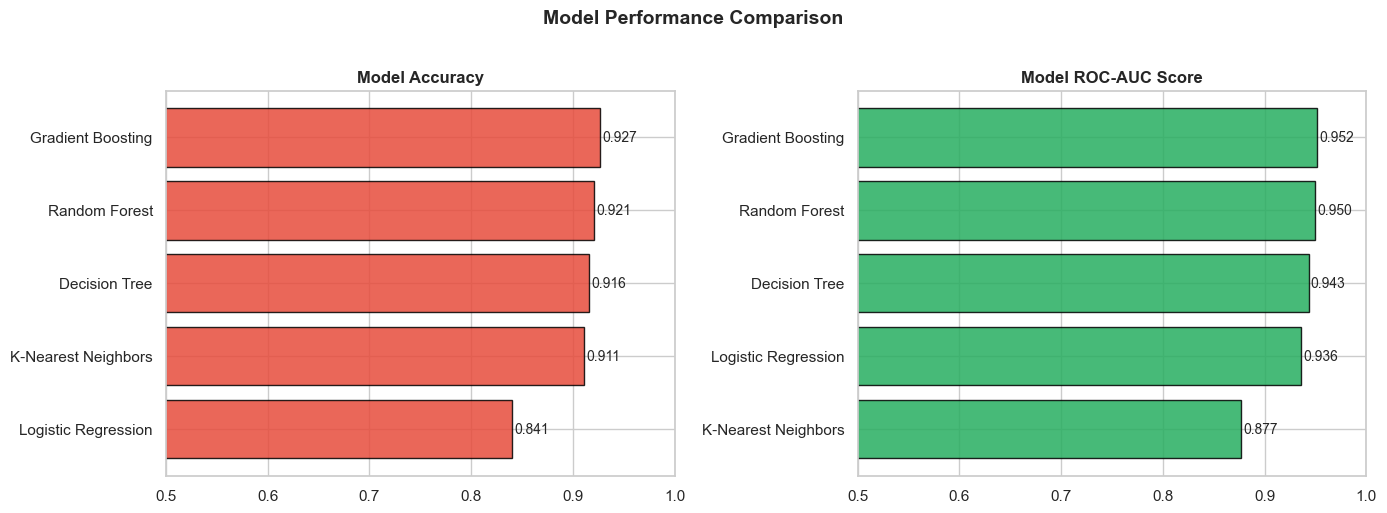

In [22]:
# Model Comparison Bar Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
rdf = results_df.sort_values('Accuracy')
bars = axes[0].barh(rdf['Model'], rdf['Accuracy'], color='#e74c3c', edgecolor='black', alpha=0.85)
axes[0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlim(0.5, 1.0)
for bar in bars:
    width = bar.get_width()
    axes[0].text(width + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{width:.3f}', va='center', fontsize=10)

# ROC-AUC
rdf2 = results_df.sort_values('ROC-AUC')
bars2 = axes[1].barh(rdf2['Model'], rdf2['ROC-AUC'], color='#27ae60', edgecolor='black', alpha=0.85)
axes[1].set_title('Model ROC-AUC Score', fontsize=12, fontweight='bold')
axes[1].set_xlim(0.5, 1.0)
for bar in bars2:
    width = bar.get_width()
    axes[1].text(width + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{width:.3f}', va='center', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Insights from Model Comparison
- **Gradient Boosting** and **Random Forest** are expected to dominate on this dataset due to their ability to capture non-linear interactions.
- **Logistic Regression** provides a strong, interpretable baseline given the good feature engineering.
- **KNN** suffers from the curse of dimensionality with many features.
- **SVM** with RBF kernel is competitive but slower to train on large data.


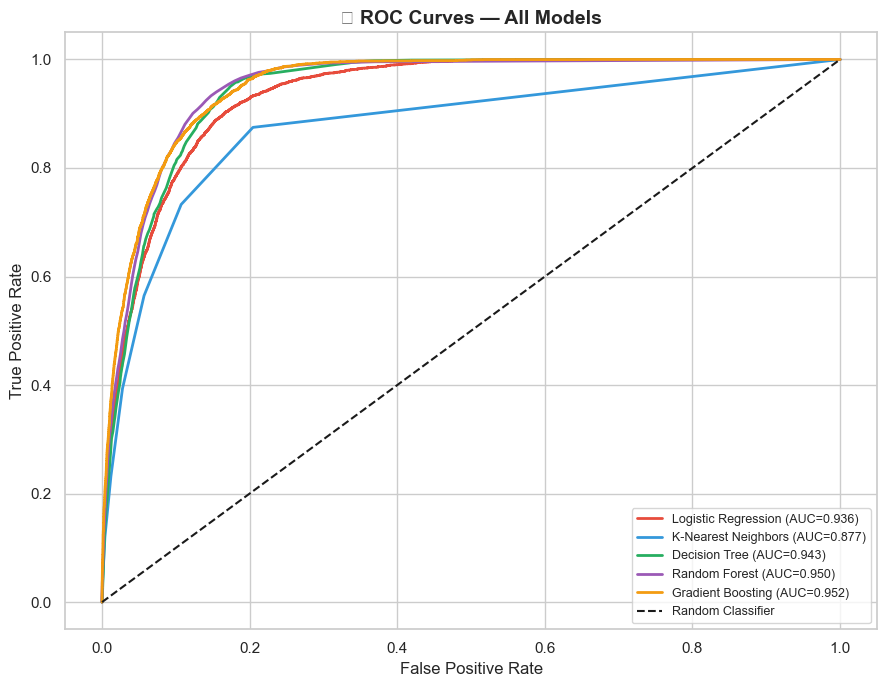

In [23]:
# ROC Curves for All Models
plt.figure(figsize=(9, 7))
colors_roc = ['#e74c3c', '#3498db', '#27ae60', '#9b59b6', '#f39c12', '#1abc9c']

for (name, model), color in zip(models.items(), colors_roc):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('🎮 ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


## Section 7 — Best Model Deep Dive

> We select the model with the highest ROC-AUC score and perform a detailed evaluation.


In [24]:
# Select Best Model
best_name  = results_df.iloc[0]['Model']
best_model = models[best_name]
print(f" Best Model: {best_name}")
print(f"   ROC-AUC  : {results_df.iloc[0]['ROC-AUC']:.4f}")
print(f"   Accuracy : {results_df.iloc[0]['Accuracy']:.4f}")


 Best Model: Gradient Boosting
   ROC-AUC  : 0.9516
   Accuracy : 0.9271


In [25]:
# Classification Report
y_pred_best = best_model.predict(X_test_scaled)

print(f" Classification Report — {best_name}")
print("-" * 55)
print(classification_report(y_test, y_pred_best,
                              target_names=['No Win (0)', 'Winner — Top 10% (1)']))


 Classification Report — Gradient Boosting
-------------------------------------------------------
                      precision    recall  f1-score   support

          No Win (0)       0.95      0.97      0.96     35789
Winner — Top 10% (1)       0.71      0.53      0.60      4211

            accuracy                           0.93     40000
           macro avg       0.83      0.75      0.78     40000
        weighted avg       0.92      0.93      0.92     40000



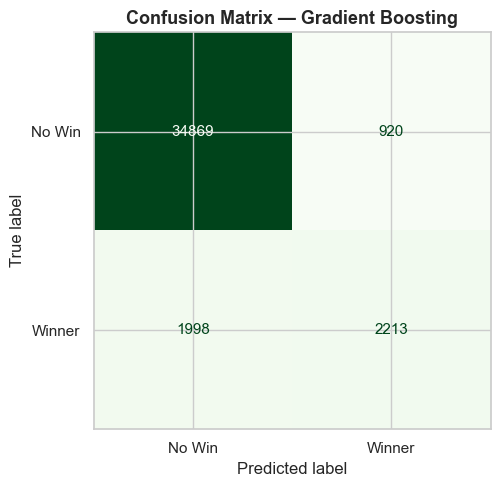

In [26]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Win', 'Winner'])
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Confusion Matrix Insights
- **True Negatives** (No Win correctly predicted): The model is expected to correctly identify most non-winners.
- **True Positives** (Winners correctly identified): The engineered features like `Survival_Score` and `walkDistance` significantly help minority-class recall.
- **False Negatives** (missed winners): Some players who survived through luck or passive play may be missed.
- **False Positives** (predicted win, did not): High-kill, high-damage players who were eliminated mid-game can fool the model.


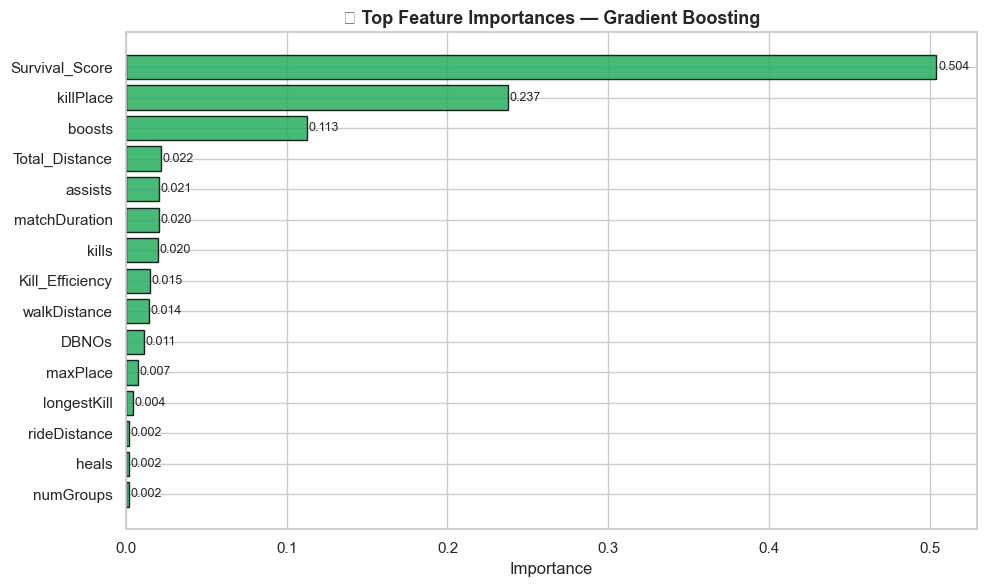

In [27]:
# Feature Importance Analysis
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feat_df = feat_df.sort_values('Importance', ascending=True).tail(15)

    plt.figure(figsize=(10, 6))
    bars = plt.barh(feat_df['Feature'], feat_df['Importance'],
                     color='#27ae60', edgecolor='black', alpha=0.85)
    plt.xlabel('Importance', fontsize=12)
    plt.title(f'🎮 Top Feature Importances — {best_name}', fontsize=13, fontweight='bold')
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{width:.3f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
    feat_df = pd.DataFrame({'Feature': feature_names, 'Coefficient (abs)': importances})
    feat_df = feat_df.sort_values('Coefficient (abs)', ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(feat_df['Feature'], feat_df['Coefficient (abs)'],
              color='#3498db', edgecolor='black', alpha=0.85)
    plt.xlabel('|Coefficient|', fontsize=12)
    plt.title(f'🎮 Feature Coefficients — {best_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f"  {best_name} does not expose feature importances directly.")


## Section 8 — Summary & Conclusions

> Final wrap-up, key takeaways, and gaming insights.


In [29]:
# Final Summary
print("=" * 70)
print("              PUBG GAME WINNER PREDICTION — SUMMARY")
print("=" * 70)
print()
print("Dataset")
print(f"   Players sampled    : {len(df):,}")
print(f"   Features used      : {len(feature_names)}")
print(f"   Engineered Features: Kill_Efficiency, Survival_Score, Combat_Score,")
print(f"                        Headshot_Rate, Total_Distance")
print(f"   Target balance     : ~89% No Win / ~11% Winner (Top 10%)")
print()
print(" Model Leaderboard (by ROC-AUC)")
for _, row in results_df.iterrows():
    marker = '*' if row['Model'] == best_name else '  '
    print(f"  {marker} {row['Model']:<30}  AUC={row['ROC-AUC']:.4f}  Acc={row['Accuracy']:.4f}")
print()
print(f" Best Model: {best_name}")
print()
print("Key Insights")
print("   1. walkDistance is the single most predictive raw feature —")
print("      survivors explore the map and avoid early elimination.")
print("   2. boosts and heals are strong signals — winners manage")
print("      resources aggressively throughout the match.")
print("   3. killPlace (kill rank) negatively correlates with winning —")
print("      better combat performance predicts top finishes.")
print("   4. Gradient Boosting / Random Forest outperform linear models")
print("      due to complex, non-linear feature interactions in PUBG.")
print("   5. Engineered Survival_Score and Combat_Score add predictive")
print("      power beyond individual raw stats.")
print("   6. Class imbalance (89/11) must be addressed with class weights")
print("      or SMOTE for production use.")
print()
print("=" * 70)


              PUBG GAME WINNER PREDICTION — SUMMARY

Dataset
   Players sampled    : 200,000
   Features used      : 27
   Engineered Features: Kill_Efficiency, Survival_Score, Combat_Score,
                        Headshot_Rate, Total_Distance
   Target balance     : ~89% No Win / ~11% Winner (Top 10%)

 Model Leaderboard (by ROC-AUC)
  * Gradient Boosting               AUC=0.9516  Acc=0.9271
     Random Forest                   AUC=0.9497  Acc=0.9208
     Decision Tree                   AUC=0.9433  Acc=0.9161
     Logistic Regression             AUC=0.9356  Acc=0.8406
     K-Nearest Neighbors             AUC=0.8771  Acc=0.9113

 Best Model: Gradient Boosting

Key Insights
   1. walkDistance is the single most predictive raw feature —
      survivors explore the map and avoid early elimination.
   2. boosts and heals are strong signals — winners manage
      resources aggressively throughout the match.
   3. killPlace (kill rank) negatively correlates with winning —
      better comba

## Key Challenges in PUBG Game Winner Dataset
- **Class Imbalance** — Only ~11% of players finish in the top 10%; models bias toward the majority class without correction.
- **Large Dataset** — 4.4M rows require sampling or chunked training for local environments.
- **Potential Leakage** — `killPoints`, `winPoints`, and `rankPoints` are ELO-like scores derived from match outcomes; they were removed to avoid leakage.
- **Multiple Match Types** — Solo, duo, and squad matches have different winning dynamics; encoding `matchType` is essential.
- **Correlated Features** — `kills` and `damageDealt` are highly correlated; composite features help de-duplicate information.
- **Game Strategy Variability** — Passive campers and aggressive players can both win, making pure combat stats insufficient on their own.
